# Supply Chain — Preprocessing & Feature Engineering QA
**Purpose:** Standalone notebook to validate the full feature engineering pipeline on both new datasets before integrating with the Airflow DAG.  
**Datasets:** `better_retail_store_inventory.csv` · `better_inventory_snapshot.csv`  
**Pipeline version:** 2.0

---
## 0. Imports & Config

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# ── Paths — update if your CSVs are elsewhere ─────────────────────────────────
RETAIL_PATH   = 'better_retail_store_inventory.csv'
SNAPSHOT_PATH = 'better_inventory_snapshot.csv'
HORIZON       = 1   # forecast horizon in days

# ── Schema constants (mirrors data_pipeline.py v2.0) ─────────────────────────
REQUIRED_COLS = [
    'Date', 'Store ID', 'Product ID', 'Category', 'Region',
    'Units Sold', 'Inventory Level', 'Units Ordered',
    'Demand Forecast', 'Price', 'Discount',
    'Holiday/Promotion', 'Competitor Pricing', 'Seasonality',
]
SNAPSHOT_REQUIRED_COLS = ['Store ID', 'Product ID', 'Lead Time Days']

FEATURE_COLS = [
    'sales_lag_1', 'sales_lag_7', 'sales_lag_14', 'sales_lag_28',
    'sales_roll_mean_7', 'sales_roll_mean_14', 'sales_roll_mean_28',
    'sales_roll_std_7', 'sales_ewm_28',
    'demand_forecast_lag1',
    'price_vs_competitor', 'effective_price',
    'Holiday/Promotion', 'Discount', 'discount_x_holiday',
    'dow', 'month', 'is_weekend',
    'Inventory Level', 'stockout_flag', 'lead_time_demand',
    'Lead Time Days', 'reorder_event',
    'Category_enc', 'Region_enc', 'Seasonality_enc',
    'y_pred_baseline', 'sample_weight',
]

print('Config loaded. Horizon:', HORIZON)

Config loaded. Horizon: 1


---
## 1. Load Raw Data

In [38]:
retail = pd.read_csv(RETAIL_PATH)
snap   = pd.read_csv(SNAPSHOT_PATH)

print(f'Retail  : {retail.shape[0]:,} rows × {retail.shape[1]} cols')
print(f'Snapshot: {snap.shape[0]:,} rows × {snap.shape[1]} cols')
retail.head(3)

Retail  : 73,100 rows × 15 cols
Snapshot: 100 rows × 8 cols


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,890,121,0,136.63,31.90,15,Cloudy,1,38.84,Winter
1,2022-01-02,S001,P0001,Groceries,North,769,101,0,93.67,37.14,0,Sunny,1,35.95,Winter
2,2022-01-03,S001,P0001,Groceries,North,668,77,0,64.13,37.69,0,Snowy,0,36.29,Winter


In [39]:
snap.head(3)

,Store ID,Product ID,Category,Region,Current Stock,Total Units Sold,Total Units Received,Lead Time Days
0,S001,P0001,Groceries,North,4865,66497,70472,4
1,S001,P0002,Beverages,North,6460,38008,44093,7
2,S001,P0003,Household,North,1031,28820,29474,2


---
## 2. Schema Validation

In [40]:
missing_retail = [c for c in REQUIRED_COLS if c not in retail.columns]
missing_snap   = [c for c in SNAPSHOT_REQUIRED_COLS if c not in snap.columns]

print('Missing in retail  :', missing_retail   or 'None ✓')
print('Missing in snapshot:', missing_snap     or 'None ✓')
print()
print('Retail dtypes:')
print(retail.dtypes.to_string())

Missing in retail  : None ✓
Missing in snapshot: None ✓

Retail dtypes:
Date                   object
Store ID               object
Product ID             object
Category               object
Region                 object
Inventory Level         int64
Units Sold              int64
Units Ordered           int64
Demand Forecast       float64
Price                 float64
Discount                int64
Weather Condition      object
Holiday/Promotion       int64
Competitor Pricing    float64
Seasonality            object


---
## 3. Raw Data Quality Checks

In [41]:
# Nulls
null_summary = retail.isnull().sum().rename('null_count')
null_summary = null_summary[null_summary > 0]
print('Columns with nulls:')
print(null_summary if len(null_summary) else 'None ✓')

Columns with nulls:
None ✓


In [42]:
# Duplicates
dupes = retail.duplicated(subset=['Date', 'Store ID', 'Product ID']).sum()
print(f'Duplicate (Date, Store ID, Product ID) rows: {dupes}')

# Negative values
for col in ['Units Sold', 'Inventory Level']:
    neg = (retail[col] < 0).sum()
    print(f'Negative values in {col}: {neg}')

Duplicate (Date, Store ID, Product ID) rows: 0
Negative values in Units Sold: 0
Negative values in Inventory Level: 0


In [43]:
# Cardinality & date range
retail['Date'] = pd.to_datetime(retail['Date'])
print(f"Date range     : {retail['Date'].min().date()} → {retail['Date'].max().date()}")
print(f"Unique stores  : {retail['Store ID'].nunique()}")
print(f"Unique products: {retail['Product ID'].nunique()}")
print(f"Unique series  : {retail.groupby(['Store ID','Product ID']).ngroups}")
print(f"Categories     : {sorted(retail['Category'].unique())}")
print(f"Regions        : {sorted(retail['Region'].unique())}")
print(f"Seasonality    : {sorted(retail['Seasonality'].unique())}")
print(f"Weather        : {sorted(retail['Weather Condition'].unique())}")

Date range     : 2022-01-01 → 2024-01-01
Unique stores  : 5
Unique products: 20
Unique series  : 100
Categories     : ['Beverages', 'Groceries', 'Household', 'Personal Care', 'Snacks']
Regions        : ['Central', 'East', 'North', 'South', 'West']
Seasonality    : ['Autumn', 'Spring', 'Summer', 'Winter']
Weather        : ['Cloudy', 'Rainy', 'Snowy', 'Sunny']


In [44]:
# Units Sold distribution
retail['Units Sold'].describe().round(2)

count    73100.00
mean        73.62
std         37.35
min          0.00
25%         46.00
50%         66.00
75%         93.00
max        406.00
Name: Units Sold, dtype: float64

---
## 4. Preprocessing

In [45]:
df = retail.copy()

# 4a. Drop duplicates
before = len(df)
df = df.drop_duplicates(subset=['Date', 'Store ID', 'Product ID'])
print(f'Duplicates removed : {before - len(df)}')

# 4b. Clip negatives
for col in ['Units Sold', 'Inventory Level']:
    neg = (df[col] < 0).sum()
    if neg:
        print(f'Clipping {neg} negatives in {col}')
    df[col] = df[col].clip(lower=0)

# 4c. Sort
df = df.sort_values(['Store ID', 'Product ID', 'Date']).reset_index(drop=True)

# 4d. Snapshot join
df = df.merge(snap[['Store ID', 'Product ID', 'Lead Time Days']],
              on=['Store ID', 'Product ID'], how='left')
missing_lead = df['Lead Time Days'].isnull().sum()
if missing_lead:
    print(f'Filling {missing_lead} missing Lead Time Days with median')
    df['Lead Time Days'] = df['Lead Time Days'].fillna(df['Lead Time Days'].median())

print(f'Shape after preprocessing: {df.shape}')
df[['Store ID', 'Product ID', 'Date', 'Units Sold', 'Lead Time Days']].head(3)

df['series_id'] = df['Store ID'].astype(str) + '_' + df['Product ID'].astype(str)

print(f'Shape after preprocessing: {df.shape}')
df[['series_id', 'Store ID', 'Product ID', 'Date', 'Units Sold', 'Lead Time Days']].head(3)


Duplicates removed : 0
Shape after preprocessing: (73100, 16)
Shape after preprocessing: (73100, 17)


,series_id,Store ID,Product ID,Date,Units Sold,Lead Time Days
0,S001_P0001,S001,P0001,2022-01-01,121,4
1,S001_P0001,S001,P0001,2022-01-02,101,4
2,S001_P0001,S001,P0001,2022-01-03,77,4


---
## 5. Feature Engineering

In [46]:
gs = df.groupby(['Store ID', 'Product ID'])['Units Sold']

# ── Lag features ─────────────────────────────────────────────────────────────
df['sales_lag_1']  = gs.shift(1)
df['sales_lag_7']  = gs.shift(7)
df['sales_lag_14'] = gs.shift(14)
df['sales_lag_28'] = gs.shift(28)

# ── Rolling statistics ────────────────────────────────────────────────────────
df['sales_roll_mean_7']  = gs.transform(lambda x: x.rolling(7,  min_periods=3).mean().shift(1))
df['sales_roll_mean_14'] = gs.transform(lambda x: x.rolling(14, min_periods=7).mean().shift(1))
df['sales_roll_mean_28'] = gs.transform(lambda x: x.rolling(28, min_periods=7).mean().shift(1))
df['sales_roll_std_7']   = gs.transform(lambda x: x.rolling(7,  min_periods=3).std().shift(1))
df['sales_ewm_28']       = gs.transform(lambda x: x.shift(1).ewm(span=28, adjust=False).mean())

# ── Demand forecast (lagged — prevents same-day leakage) ─────────────────────
df['demand_forecast_lag1'] = df.groupby(['Store ID', 'Product ID'])['Demand Forecast'].shift(1)

# ── Pricing ───────────────────────────────────────────────────────────────────
df['price_vs_competitor'] = df['Price'] / df['Competitor Pricing'].clip(lower=0.01)
df['effective_price']     = df['Price'] * (1 - df['Discount'] / 100)

# ── Inventory position ────────────────────────────────────────────────────────
df['stockout_flag']    = (df['Inventory Level'] == 0).astype(int)
df['reorder_event']    = (df['Units Ordered'] > 0).astype(int)
df['lead_time_demand'] = df['sales_roll_mean_7'].clip(lower=0) * df['Lead Time Days']

# ── Promotional & calendar ────────────────────────────────────────────────────
df['discount_x_holiday'] = df['Discount'] * df['Holiday/Promotion']
df['dow']       = df['Date'].dt.dayofweek
df['month']     = df['Date'].dt.month
df['is_weekend'] = (df['Date'].dt.dayofweek >= 5).astype(int)

# ── Categorical encoding ──────────────────────────────────────────────────────
category_order = ['Groceries', 'Snacks', 'Beverages', 'Household', 'Personal Care']
df['Category_enc']    = pd.Categorical(df['Category'], categories=category_order).codes
df['Region_enc']      = df['Region'].map({'North':0,'South':1,'East':2,'West':3,'Central':4}).fillna(-1).astype(int)
df['Seasonality_enc'] = df['Seasonality'].map({'Winter':0,'Spring':1,'Summer':2,'Autumn':3}).fillna(-1).astype(int)

# ── Baseline prediction ───────────────────────────────────────────────────────
df['y_pred_baseline'] = df['sales_lag_1'].fillna(df['sales_lag_7']) if HORIZON == 1 else df['sales_lag_7']

# ── Sample weights ────────────────────────────────────────────────────────────
store_freq = df['Store ID'].value_counts(normalize=True)
df['sample_weight'] = df['Store ID'].map(lambda x: 1.0 / max(store_freq.get(x, 0), 1e-6)).clip(0.1, 10.0)

# ── Label ─────────────────────────────────────────────────────────────────────
df['y'] = df.groupby(['Store ID', 'Product ID'])['Units Sold'].shift(-HORIZON)

print('All features engineered.')

All features engineered.


---
## 6. Drop Warm-up Rows & Finalize

In [47]:
rows_before = len(df)
df = df.dropna(subset=['sales_lag_28', 'y']).reset_index(drop=True)
rows_dropped = rows_before - len(df)

print(f'Rows before drop : {rows_before:,}')
print(f'Rows dropped     : {rows_dropped:,}  ({rows_dropped/rows_before*100:.1f}%)')
print(f'Rows remaining   : {len(df):,}')
print(f'Features         : {len(FEATURE_COLS)}')

Rows before drop : 73,100
Rows dropped     : 2,900  (4.0%)
Rows remaining   : 70,200
Features         : 28


---
## 7. Feature Null Check

In [48]:
null_counts = df[FEATURE_COLS + ['y']].isnull().sum()
has_nulls   = null_counts[null_counts > 0]

if len(has_nulls) == 0:
    print('✓ Zero nulls across all feature columns and label.')
else:
    print('⚠ Columns with remaining nulls:')
    print(has_nulls)

✓ Zero nulls across all feature columns and label.


---
## 8. Feature Statistics

In [49]:
df[FEATURE_COLS].describe().T[['mean','std','min','max']].round(3)

,mean,std,min,max
sales_lag_1,73.448,37.181,0.000,406.000
sales_lag_7,73.348,37.120,0.000,406.000
sales_lag_14,73.273,37.100,0.000,406.000
sales_lag_28,73.120,37.124,0.000,406.000
sales_roll_mean_7,73.382,31.055,18.143,212.714
sales_roll_mean_14,73.326,30.511,19.357,190.571
sales_roll_mean_28,73.243,30.208,20.500,181.786
sales_roll_std_7,18.811,11.409,1.272,116.025
sales_ewm_28,73.332,30.213,20.872,183.605
demand_forecast_lag1,73.755,36.937,11.910,382.610


---
## 9. Feature Correlations with Target (y)

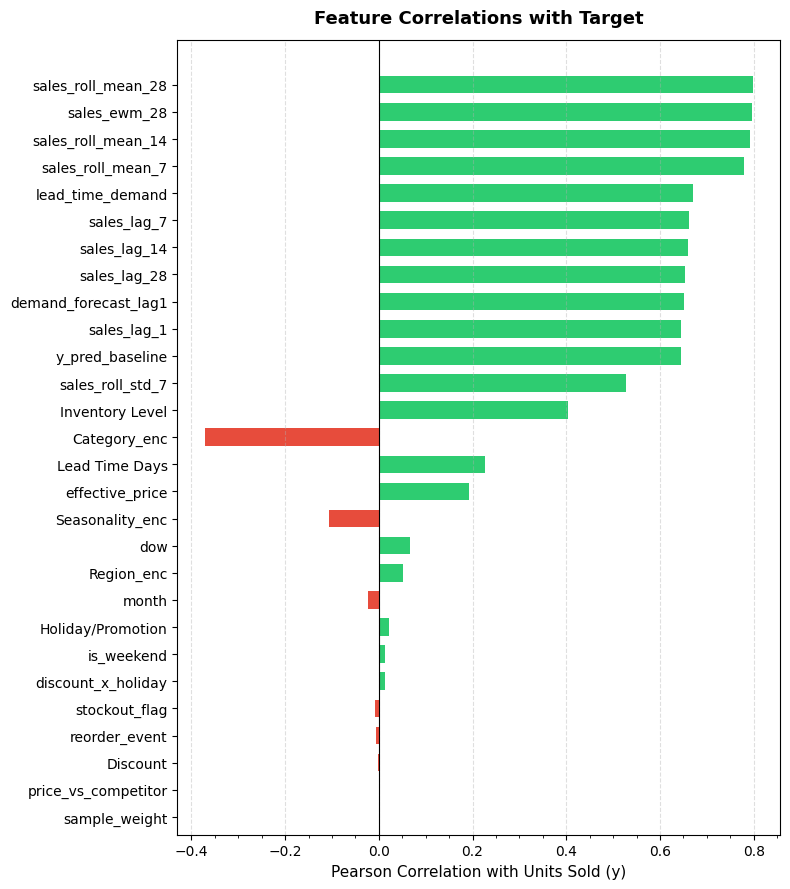


Top 10 by absolute correlation:
sales_roll_mean_28      0.798
sales_ewm_28            0.796
sales_roll_mean_14      0.792
sales_roll_mean_7       0.780
lead_time_demand        0.670
sales_lag_7             0.662
sales_lag_14            0.659
sales_lag_28            0.653
demand_forecast_lag1    0.652
sales_lag_1             0.644


In [50]:
corr = df[FEATURE_COLS + ['y']].corr()['y'].drop('y').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, 9))
colors = ['#2ecc71' if v >= 0 else '#e74c3c' for v in corr.values]
ax.barh(corr.index[::-1], corr.values[::-1], color=colors[::-1], height=0.65)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson Correlation with Units Sold (y)', fontsize=11)
ax.set_title('Feature Correlations with Target', fontsize=13, fontweight='bold', pad=12)
ax.xaxis.set_minor_locator(mticker.AutoMinorLocator())
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print('\nTop 10 by absolute correlation:')
print(corr.head(10).round(3).to_string())

---
## 10. Leakage Sanity Check

In [51]:
same_day_leakage = {
    'demand_forecast_lag1 == Demand Forecast (same day)': (df['demand_forecast_lag1'] == df['Demand Forecast']).mean(),
    'sales_lag_1 == Units Sold (same day)':               (df['sales_lag_1'] == df['Units Sold']).mean(),
    'y_pred_baseline == y (label)':                       (df['y_pred_baseline'] == df['y']).mean(),
}

# sales_lag_1 and y_pred_baseline can coincidentally equal same-day values
# when consecutive days have identical sales — not true leakage.
# Only flag demand_forecast_lag1 strictly (should be near 0).
# For lag/baseline, flag only if > 50% match (which would indicate a real shift error).
thresholds = {
    'demand_forecast_lag1 == Demand Forecast (same day)': 0.01,
    'sales_lag_1 == Units Sold (same day)':               0.50,
    'y_pred_baseline == y (label)':                       0.50,
}

print('Leakage checks:')
for desc, val in same_day_leakage.items():
    flag = '✓' if val < thresholds[desc] else '⚠ POSSIBLE LEAKAGE'
    print(f'  {flag}  {desc}: {val:.4f}')

print()
sample = df[df['series_id'] == df['series_id'].iloc[0]].head(5)[['Date', 'Units Sold', 'y']]
print("Label sanity (y should be next row's Units Sold):")
print(sample.to_string(index=False))

Leakage checks:
  ✓  demand_forecast_lag1 == Demand Forecast (same day): 0.0002
  ✓  sales_lag_1 == Units Sold (same day): 0.0217
  ✓  y_pred_baseline == y (label): 0.0205

Label sanity (y should be next row's Units Sold):
      Date  Units Sold     y
2022-01-29          87  80.0
2022-01-30          80  91.0
2022-01-31          91  77.0
2022-02-01          77 106.0
2022-02-02         106  82.0


---
## 11. Distribution Plots — Key Features

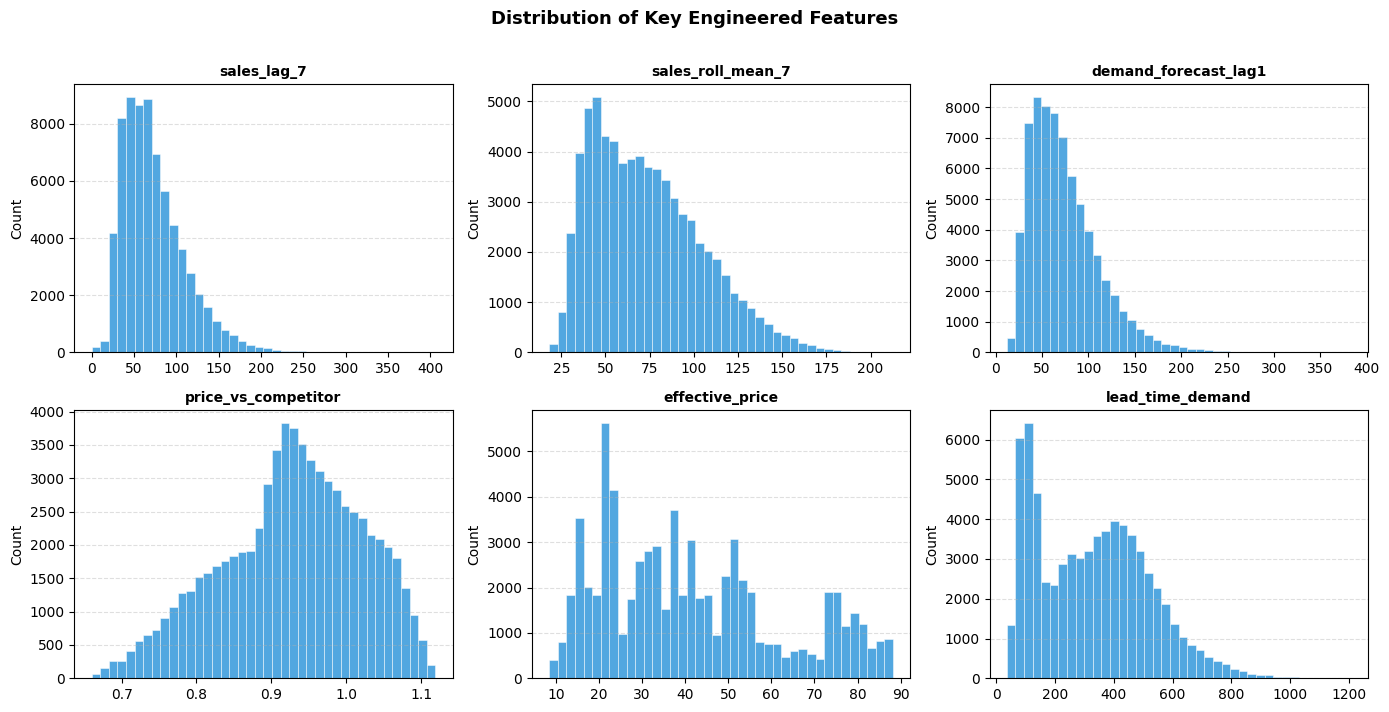

In [52]:
plot_features = [
    'sales_lag_7', 'sales_roll_mean_7', 'demand_forecast_lag1',
    'price_vs_competitor', 'effective_price', 'lead_time_demand',
]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, feat in zip(axes.flat, plot_features):
    data = df[feat].dropna()
    ax.hist(data, bins=40, color='#3498db', edgecolor='white', linewidth=0.4, alpha=0.85)
    ax.set_title(feat, fontsize=10, fontweight='bold')
    ax.set_ylabel('Count')
    ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle('Distribution of Key Engineered Features', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 12. Sales by Category, Seasonality, Day-of-Week

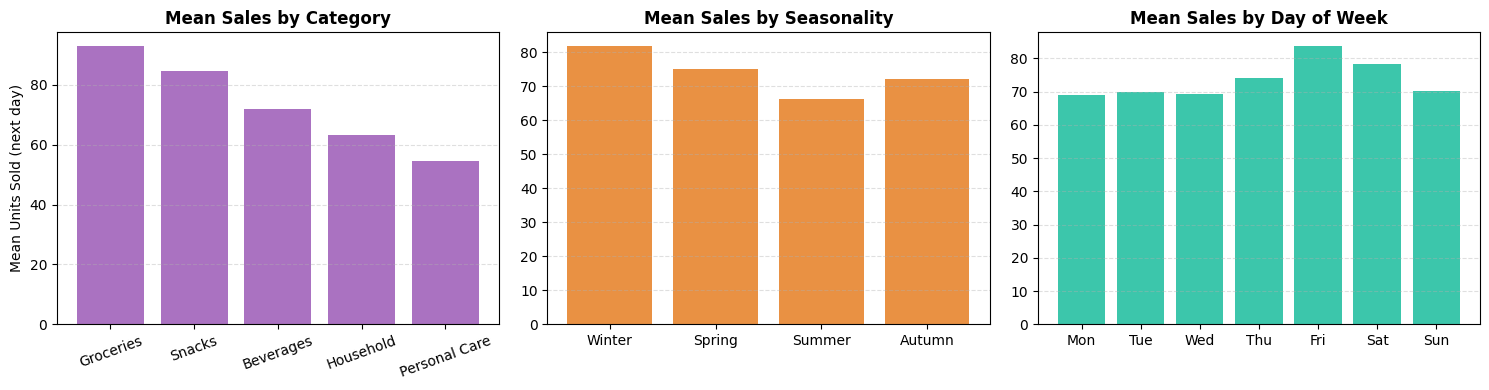

In [53]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Category
cat_means = df.groupby('Category')['y'].mean().sort_values(ascending=False)
axes[0].bar(cat_means.index, cat_means.values, color='#9b59b6', alpha=0.85)
axes[0].set_title('Mean Sales by Category', fontweight='bold')
axes[0].set_ylabel('Mean Units Sold (next day)')
axes[0].tick_params(axis='x', rotation=20)
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

# Seasonality
season_order = ['Winter', 'Spring', 'Summer', 'Autumn']
season_means = df.groupby('Seasonality')['y'].mean().reindex(season_order)
axes[1].bar(season_means.index, season_means.values, color='#e67e22', alpha=0.85)
axes[1].set_title('Mean Sales by Seasonality', fontweight='bold')
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

# Day of week
dow_map = {0:'Mon',1:'Tue',2:'Wed',3:'Thu',4:'Fri',5:'Sat',6:'Sun'}
dow_means = df.groupby('dow')['y'].mean()
axes[2].bar([dow_map[i] for i in dow_means.index], dow_means.values, color='#1abc9c', alpha=0.85)
axes[2].set_title('Mean Sales by Day of Week', fontweight='bold')
axes[2].grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

---
## 13. Stockout & Reorder Event Rates

In [54]:
print(f"Stockout rate    : {df['stockout_flag'].mean()*100:.2f}% of rows")
print(f"Reorder event    : {df['reorder_event'].mean()*100:.2f}% of rows")
print(f"Holiday rate     : {df['Holiday/Promotion'].mean()*100:.2f}% of rows")
print(f"Weekend rate     : {df['is_weekend'].mean()*100:.2f}% of rows")
print()
print('Mean y when stockout_flag=1 :', df.loc[df['stockout_flag']==1, 'y'].mean().round(2))
print('Mean y when stockout_flag=0 :', df.loc[df['stockout_flag']==0, 'y'].mean().round(2))
print()
print('Mean y on holidays           :', df.loc[df['Holiday/Promotion']==1, 'y'].mean().round(2))
print('Mean y on non-holidays       :', df.loc[df['Holiday/Promotion']==0, 'y'].mean().round(2))

Stockout rate    : 0.54% of rows
Reorder event    : 5.79% of rows
Holiday rate     : 4.88% of rows
Weekend rate     : 28.77% of rows

Mean y when stockout_flag=1 : 68.88
Mean y when stockout_flag=0 : 73.53

Mean y on holidays           : 77.08
Mean y on non-holidays       : 73.32


---
## 14. Series Coverage Check

In [55]:
df['series_id'] = df['Store ID'].astype(str) + '_' + df['Product ID'].astype(str)

series_counts = df.groupby('series_id')['Date'].count().rename('n_rows')
print(f'Total series           : {series_counts.shape[0]}')
print(f'Min rows per series    : {series_counts.min()}')
print(f'Max rows per series    : {series_counts.max()}')
print(f'Mean rows per series   : {series_counts.mean():.0f}')
print(f'Series with < 100 rows : {(series_counts < 100).sum()}')

Total series           : 100
Min rows per series    : 702
Max rows per series    : 702
Mean rows per series   : 702
Series with < 100 rows : 0


---
## 15. Final Feature Matrix — Ready for Modeling

In [56]:
X = df[FEATURE_COLS]
y = df['y']

print('X shape :', X.shape)
print('y shape :', y.shape)
print('y stats :')
print(y.describe().round(2))
print()
print('Feature matrix preview:')
X.head(3)

X shape : (70200, 28)
y shape : (70200,)
y stats :
count    70200.00
mean        73.51
std         37.24
min          0.00
25%         46.00
50%         66.00
75%         93.00
max        406.00
Name: y, dtype: float64

Feature matrix preview:


,sales_lag_1,sales_lag_7,sales_lag_14,sales_lag_28,sales_roll_mean_7,sales_roll_mean_14,sales_roll_mean_28,sales_roll_std_7,sales_ewm_28,demand_forecast_lag1,...,Inventory Level,stockout_flag,lead_time_demand,Lead Time Days,reorder_event,Category_enc,Region_enc,Seasonality_enc,y_pred_baseline,sample_weight
0,88.0,100.0,80.0,121.0,105.285714,95.857143,98.500000,14.056010,101.880803,65.91,...,4406,0,421.142857,4,0,0,0,0,88.0,5.0
1,87.0,133.0,98.0,101.0,103.428571,96.357143,97.285714,15.640302,100.854541,75.67,...,4319,0,413.714286,4,0,0,0,0,87.0,5.0
2,80.0,97.0,78.0,77.0,95.857143,95.071429,96.535714,11.111984,99.416297,102.25,...,4239,0,383.428571,4,0,0,0,0,80.0,5.0


In [57]:
# Optional: export feature matrix to CSV for model testing
# df[['series_id', 'Date'] + FEATURE_COLS + ['y']].to_csv('features_v2.csv', index=False)
# print('Exported to features_v2.csv')

print('Notebook complete. X and y are ready for Prophet / XGBoost / LSTM.')

Notebook complete. X and y are ready for Prophet / XGBoost / LSTM.
